# Comparing Models

Features are fixed, models compared on identical splits.

## Models

- Logistic Regression L1 and L2 as baseline
- Random Forest for non linear effects
- XGBoost for boosted trees

## Goal

- Check if non linear models add signal over linear baseline  
- Understand if signal is mostly linear or not  

## Evaluation

- AUC across folds  
- Stability of AUC across time  
- Accuracy in top quantiles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from microstructure_alpha.data.loader import load_parquet_glob
from microstructure_alpha.features.feature_lists import MID_PRICE_MOVE_FINAL
from microstructure_alpha.models.model_configs import (
    calibrate_model,
    LINEAR_MODELS,
    TREE_MODELS,
    OTHER_MODELS,
)
from microstructure_alpha.models.train import run_model_parallel, run_fold
from microstructure_alpha.plots import plot_fold_aucs, plot_rolling_calibration
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
target = "mid_price_moves"

final_dataset = load_parquet_glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet",
    sort_by="timestamp",
)

In [3]:
splits = 10
size_data = len(final_dataset)

tscv = TimeSeriesSplit(n_splits=splits, gap=50, max_train_size=int(size_data / splits))

In [4]:
X = final_dataset[MID_PRICE_MOVE_FINAL]
y = final_dataset[target]

In [5]:
ALL_MODELS = {**LINEAR_MODELS, **TREE_MODELS, **OTHER_MODELS}

In [6]:
all_results = {}

for name, model in ALL_MODELS.items():

    scale = "logreg" in name
    calibrate = False
    all_results[name] = run_model_parallel(
        X,
        y,
        model,
        tscv,
        n_jobs=4,
        scale=scale,
        calibrate=calibrate,
    )

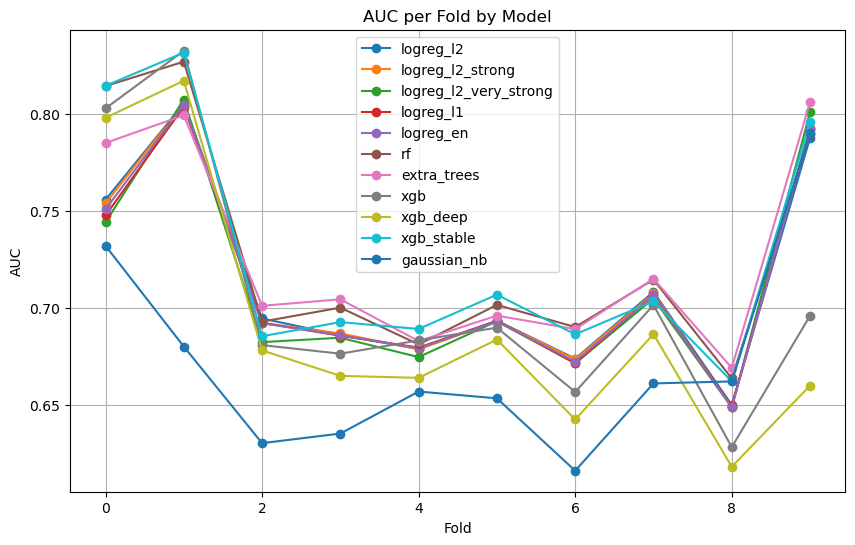

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, res in all_results.items():
    aucs = res["fold_aucs"]
    plt.plot(aucs, marker="o", label=name)

plt.xlabel("Fold")
plt.ylabel("AUC")
plt.title("AUC per Fold by Model")
plt.legend()
plt.grid(True)

plt.show()

### AUC Stability

- Most models cluster closely across folds, suggesting similar signal extraction  
- XGBoost stable and consistently among the top performers  
- Random Forest and Extra Trees slightly more variable  
- Gaussian NB clearly underperforms  

Conclusion  
- Signal appears largely linear with some small non linear improvements

In [8]:
from microstructure_alpha.models.model_configs import build_model_summary

build_model_summary(all_results)

,mean_auc,std_auc,min_auc
model,,,
logreg_l2,0.713304,0.049032,0.649917
logreg_l2_strong,0.713214,0.049881,0.649049
logreg_l2_very_strong,0.711161,0.052032,0.648687
logreg_l1,0.712133,0.049112,0.649507
logreg_en,0.712533,0.049629,0.648888
rf,0.727412,0.056217,0.663664
extra_trees,0.724730,0.048760,0.669117
xgb,0.704751,0.060175,0.628249
xgb_deep,0.691241,0.061289,0.618127


### Model Summary

- Tree models slightly better  
- Logistic still competitive  
- XGBoost deep worse, likely overfit  

Conclusion  
- Small non linear gain  
- Signal mostly linear

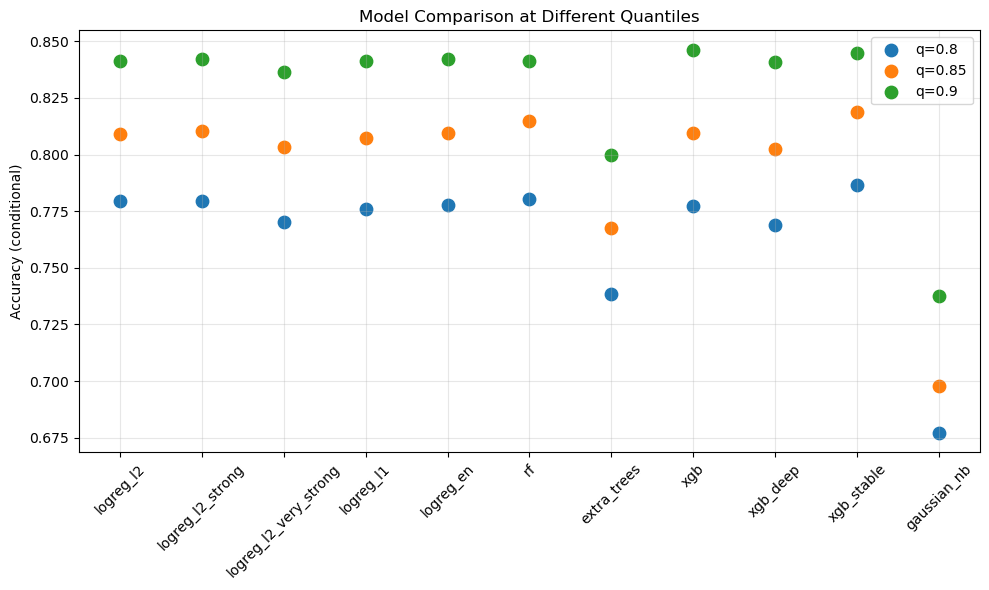

In [9]:
from microstructure_alpha.plots import plot_quantile_accuracy

quantiles = [0.8, 0.85, 0.9]
y_true = y.values
plot_quantile_accuracy(all_results, y_true, quantiles)

Random Forest is selected as the base model due to the highest mean AUC and stable performance across folds.

In [10]:
from microstructure_alpha.plots import plot_model_calibration

plot_model_calibration(
    all_results,
    y_true,
    window=500,
    figsize_per_model=3,
    show=False,
    save_path="C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\notebook_figs\\04_alpha_move_model_figs\\comparison.pdf",
)